<a href="https://colab.research.google.com/github/vaibhavjiyer87/engine-nvh-deep-learning/blob/main/notebooks/08_cnn_rpm_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 1 — Mount Google Drive

# ============================================================
# CELL 1 — MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

# Persistent project location in Google Drive
PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/"
    "NVH_DeepLearning/01_EngineOperatingState"
)

if not PROJECT_DRIVE.exists():
    raise FileNotFoundError(
        f"Project folder was not found:\n{PROJECT_DRIVE}"
    )

print("Google Drive mounted successfully.")
print(f"Project Drive: {PROJECT_DRIVE}")

Mounted at /content/drive
Google Drive mounted successfully.
Project Drive: /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState


In [2]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 2 — Authenticate GitHub + determine Git author identity
# This assumes your GitHub token is stored in Colab Secrets under:
# GITHUB_TOKEN

# ============================================================
# CELL 2 — AUTHENTICATE GITHUB
# ============================================================

from google.colab import userdata

import os
import shutil
import subprocess


# ------------------------------------------------------------
# Repository settings
# ------------------------------------------------------------

REPOSITORY_NAME = "engine-nvh-deep-learning"


# ------------------------------------------------------------
# Load GitHub token securely from Colab Secrets
# ------------------------------------------------------------

github_token = userdata.get("GITHUB_TOKEN")

if not github_token:
    raise ValueError(
        "GITHUB_TOKEN was not found in Colab Secrets.\n"
        "Add the token and enable Notebook access."
    )

# GitHub CLI recognizes GH_TOKEN automatically.
os.environ["GH_TOKEN"] = github_token
os.environ["GH_HOST"] = "github.com"


# ------------------------------------------------------------
# Install GitHub CLI if necessary
# ------------------------------------------------------------

if shutil.which("gh") is None:

    print("Installing GitHub CLI...")

    subprocess.run(
        ["apt-get", "update", "-qq"],
        check=True,
    )

    subprocess.run(
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "gh",
        ],
        check=True,
    )


# ------------------------------------------------------------
# Verify authentication
# ------------------------------------------------------------

auth_result = subprocess.run(
    [
        "gh",
        "api",
        "user",
        "--jq",
        ".login",
    ],
    capture_output=True,
    text=True,
)

if auth_result.returncode != 0:

    print(auth_result.stderr)

    raise RuntimeError(
        "GitHub authentication failed."
    )


GITHUB_USERNAME = auth_result.stdout.strip()

# ------------------------------------------------------------
# Configure Git commit identity
# ------------------------------------------------------------

user_id_result = subprocess.run(
    [
        "gh",
        "api",
        "user",
        "--jq",
        ".id",
    ],
    capture_output=True,
    text=True,
    check=True,
)

GITHUB_USER_ID = (
    user_id_result.stdout.strip()
)

GIT_NAME = GITHUB_USERNAME

GIT_EMAIL = (
    f"{GITHUB_USER_ID}+"
    f"{GITHUB_USERNAME}@users.noreply.github.com"
)

print("Git identity prepared.")
print(f"Name:  {GIT_NAME}")
print(f"Email: {GIT_EMAIL}")

# ------------------------------------------------------------
# Configure Git to use GitHub CLI authentication
# ------------------------------------------------------------

subprocess.run(
    [
        "gh",
        "auth",
        "setup-git",
        "--hostname",
        "github.com",
        "--force",
    ],
    check=True,
)


print("GitHub authentication successful.")
print(f"GitHub user: {GITHUB_USERNAME}")
print(f"Repository:  {REPOSITORY_NAME}")

Git identity prepared.
Name:  vaibhavjiyer87
Email: 312107027+vaibhavjiyer87@users.noreply.github.com
GitHub authentication successful.
GitHub user: vaibhavjiyer87
Repository:  engine-nvh-deep-learning


In [3]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 3 — Clone repository if .git is missing / Update repository
# This cell deals with the temporary nature of /content.

# ============================================================
# CELL 3 — RESTORE LOCAL GITHUB REPOSITORY
# ============================================================

from pathlib import Path
import shutil
import subprocess


TEMP_REPO_DIR = (
    Path("/content")
    / REPOSITORY_NAME
)

REPOSITORY_IDENTIFIER = (
    f"{GITHUB_USERNAME}/"
    f"{REPOSITORY_NAME}"
)


# ------------------------------------------------------------
# Case 1:
# Valid Git repository already exists
# ------------------------------------------------------------

if (
    TEMP_REPO_DIR.exists()
    and
    (TEMP_REPO_DIR / ".git").exists()
):

    print(
        "Git repository already exists "
        "in this Colab runtime."
    )

    # Pull updates only when the working tree is clean.
    status_result = subprocess.run(
        [
            "git",
            "-C",
            str(TEMP_REPO_DIR),
            "status",
            "--porcelain",
        ],
        capture_output=True,
        text=True,
        check=True,
    )

    if status_result.stdout.strip():

        print(
            "Local changes detected."
        )

        print(
            "Automatic git pull skipped "
            "to avoid overwriting local work."
        )

    else:

        print(
            "Working tree is clean. "
            "Updating from GitHub..."
        )

        pull_result = subprocess.run(
            [
                "git",
                "-C",
                str(TEMP_REPO_DIR),
                "pull",
                "--ff-only",
            ],
            capture_output=True,
            text=True,
        )

        print(pull_result.stdout)

        if pull_result.returncode != 0:
            print(pull_result.stderr)


# ------------------------------------------------------------
# Case 2:
# Folder exists, but it is NOT a Git repository
# ------------------------------------------------------------

elif TEMP_REPO_DIR.exists():

    raise RuntimeError(
        f"The folder exists but is not a Git repository:\n"
        f"{TEMP_REPO_DIR}\n\n"
        "Do not run git init. Inspect or back up the folder "
        "before removing it and rerunning this cell."
    )


# ------------------------------------------------------------
# Case 3:
# Fresh runtime — clone repository
# ------------------------------------------------------------

else:

    print(
        "Repository not present in this runtime."
    )

    print(
        f"Cloning {REPOSITORY_IDENTIFIER}..."
    )

    clone_result = subprocess.run(
        [
            "gh",
            "repo",
            "clone",
            REPOSITORY_IDENTIFIER,
            str(TEMP_REPO_DIR),
        ],
        capture_output=True,
        text=True,
    )

    print(clone_result.stdout)

    if clone_result.returncode != 0:

        print(clone_result.stderr)

        raise RuntimeError(
            "Repository clone failed."
        )


# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

if not (
    TEMP_REPO_DIR
    / ".git"
).exists():

    raise RuntimeError(
        "Repository restoration failed."
    )


print("Local Git repository is ready.")
print(f"Location: {TEMP_REPO_DIR}")

Repository not present in this runtime.
Cloning vaibhavjiyer87/engine-nvh-deep-learning...

Local Git repository is ready.
Location: /content/engine-nvh-deep-learning


In [4]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 4 — Define REPO_DIR and all standard paths + restore requirements

# ============================================================
# CELL 4 — DEFINE PROJECT PATHS
# ============================================================

from pathlib import Path


# ------------------------------------------------------------
# GitHub working repository
# ------------------------------------------------------------

REPO_DIR = (
    Path("/content")
    / REPOSITORY_NAME
)

if not (
    REPO_DIR
    / ".git"
).exists():

    raise FileNotFoundError(
        f"Valid Git repository not found at:\n"
        f"{REPO_DIR}\n\n"
        "Run Cell 3 first."
    )


# ------------------------------------------------------------
# Persistent raw dataset
# ------------------------------------------------------------

RAW_ROOT = (
    PROJECT_DRIVE
    / "data"
    / "raw"
    / "procedural_engine_sounds"
)

DATASET_ROOT = (
    RAW_ROOT
    / "dataset"
)

AUDIO_DIR = (
    DATASET_ROOT
    / "audio"
    / "A_full_set"
)


# ------------------------------------------------------------
# Persistent Google Drive manifests
# ------------------------------------------------------------

DRIVE_MANIFEST_DIR = (
    PROJECT_DRIVE
    / "data"
    / "manifests"
)


# ------------------------------------------------------------
# GitHub configuration
# ------------------------------------------------------------

CONFIG_DIR = (
    REPO_DIR
    / "configs"
)

REPORT_DIR = (
    REPO_DIR
    / "reports"
)

SPLIT_DIR = (
    REPO_DIR
    / "data"
    / "splits"
)


# ------------------------------------------------------------
# GitHub result directories
# ------------------------------------------------------------

RESULTS_DIR = (
    REPO_DIR
    / "results"
)

FIGURE_DIR = (
    RESULTS_DIR
    / "figures"
)

TABLE_DIR = (
    RESULTS_DIR
    / "tables"
)

DATA_AUDIT_FIGURE_DIR = (
    FIGURE_DIR
    / "data_audit"
)

DESIGN_FIGURE_DIR = (
    FIGURE_DIR
    / "preprocessing_design"
)

SPLIT_FIGURE_DIR = (
    FIGURE_DIR
    / "split_design"
)


# ------------------------------------------------------------
# Persistent Drive output directories
# ------------------------------------------------------------

DRIVE_OUTPUT_DIR = (
    PROJECT_DRIVE
    / "outputs"
)

DRIVE_DESIGN_TABLE_DIR = (
    DRIVE_OUTPUT_DIR
    / "tables"
    / "preprocessing_design"
)


# ------------------------------------------------------------
# Create output folders if missing
# ------------------------------------------------------------

directories_to_create = [
    CONFIG_DIR,
    REPORT_DIR,
    SPLIT_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    DATA_AUDIT_FIGURE_DIR,
    DESIGN_FIGURE_DIR,
    SPLIT_FIGURE_DIR,
    DRIVE_DESIGN_TABLE_DIR,
]

for directory in directories_to_create:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print("Project paths restored.")
print()
print(f"REPO_DIR:     {REPO_DIR}")
print(f"PROJECT_DRIVE:{PROJECT_DRIVE}")
print(f"RAW_ROOT:     {RAW_ROOT}")
print(f"AUDIO_DIR:    {AUDIO_DIR}")

# ------------------------------------------------------------
# Apply Git commit identity to cloned repository
# ------------------------------------------------------------

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "config",
        "user.name",
        GIT_NAME,
    ],
    check=True,
)

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "config",
        "user.email",
        GIT_EMAIL,
    ],
    check=True,
)

print("Git commit identity applied to repository.")

# ------------------------------------------------------------
# Restore project Python dependencies
# ------------------------------------------------------------

import subprocess

REQUIREMENTS_PATH = (
    REPO_DIR
    / "requirements.txt"
)

if not REQUIREMENTS_PATH.exists():
    raise FileNotFoundError(
        f"requirements.txt not found:\n"
        f"{REQUIREMENTS_PATH}"
    )

install_result = subprocess.run(
    [
        "python",
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(REQUIREMENTS_PATH),
    ],
    capture_output=True,
    text=True,
)

if install_result.returncode != 0:

    print(install_result.stdout)
    print(install_result.stderr)

    raise RuntimeError(
        "Project dependency installation failed."
    )

print(
    "Project Python dependencies restored."
)

Project paths restored.

REPO_DIR:     /content/engine-nvh-deep-learning
PROJECT_DRIVE:/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState
RAW_ROOT:     /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds
AUDIO_DIR:    /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds/dataset/audio/A_full_set
Git commit identity applied to repository.
Project Python dependencies restored.


In [5]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 5 — Load persistent analysis data
# This cell restores the major tables you've created so far.
# This is conditional, as some files may not exist yet depending on
# where you are in the project.

# ============================================================
# CELL 5 — LOAD PERSISTENT ANALYSIS DATA
# ============================================================

# ============================================================
# STANDARD PROJECT IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import yaml

from tqdm.auto import tqdm

print(
    "Standard project libraries imported."
)


# ------------------------------------------------------------
# 1. Raw-file manifest — REQUIRED
# ------------------------------------------------------------

RAW_MANIFEST_PATH = (
    DRIVE_MANIFEST_DIR
    / "raw_file_manifest_v001.csv"
)

if not RAW_MANIFEST_PATH.exists():

    raise FileNotFoundError(
        f"Required raw manifest not found:\n"
        f"{RAW_MANIFEST_PATH}"
    )


raw_manifest = pd.read_csv(
    RAW_MANIFEST_PATH
)

print(
    f"LOADED raw_manifest: "
    f"{raw_manifest.shape}"
)


# ------------------------------------------------------------
# 2. PREP-001 detailed target analysis — OPTIONAL
# ------------------------------------------------------------

PREP001_TARGET_PATH = (
    DRIVE_DESIGN_TABLE_DIR
    / "prep001_target_analysis_v001.csv.gz"
)

if PREP001_TARGET_PATH.exists():

    prep001_targets = pd.read_csv(
        PREP001_TARGET_PATH
    )

    print(
        f"LOADED prep001_targets: "
        f"{prep001_targets.shape}"
    )

else:

    prep001_targets = None

    print(
        "NOT FOUND: prep001 target analysis "
        "(this is okay if it has not been generated yet)."
    )


# ------------------------------------------------------------
# 3. Window candidate metrics — OPTIONAL
# ------------------------------------------------------------

WINDOW_CANDIDATE_PATH = (
    DRIVE_DESIGN_TABLE_DIR
    / "window_candidate_metrics_v001.csv.gz"
)

if WINDOW_CANDIDATE_PATH.exists():

    window_candidates = pd.read_csv(
        WINDOW_CANDIDATE_PATH
    )

    print(
        f"LOADED window_candidates: "
        f"{window_candidates.shape}"
    )

else:

    window_candidates = None

    print(
        "NOT FOUND: window candidate metrics."
    )


# ------------------------------------------------------------
# 4. Frozen SPLIT-001 file assignment — OPTIONAL
# ------------------------------------------------------------

FILE_SPLIT_PATH = (
    SPLIT_DIR
    / "file_split_v001.csv"
)

if FILE_SPLIT_PATH.exists():

    file_split = pd.read_csv(
        FILE_SPLIT_PATH
    )

    print(
        f"LOADED file_split: "
        f"{file_split.shape}"
    )

else:

    file_split = None

    print(
        "NOT FOUND: SPLIT-001 file assignment."
    )


# ============================================================
# LOAD REQUIRED FROZEN PROJECT SPECIFICATIONS
# ============================================================

import yaml


# ------------------------------------------------------------
# PREP-001 — REQUIRED
# ------------------------------------------------------------

PREPROCESSING_CONFIG_PATH = (
    CONFIG_DIR
    / "preprocessing_v001.yaml"
)

if not PREPROCESSING_CONFIG_PATH.exists():

    raise FileNotFoundError(
        "Required PREP-001 configuration is missing:\n"
        f"{PREPROCESSING_CONFIG_PATH}"
    )


try:

    with open(
        PREPROCESSING_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        preprocessing_config = (
            yaml.safe_load(file)
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "PREP-001 exists but is invalid YAML.\n"
        f"{error}"
    )


if (
    preprocessing_config[
        "specification"
    ]["preprocessing_version"]
    != "PREP-001"
):

    raise RuntimeError(
        "Unexpected preprocessing version."
    )


print(
    "LOADED preprocessing_config: PREP-001"
)


# ------------------------------------------------------------
# SPLIT-001 — REQUIRED
# ------------------------------------------------------------

SPLIT_CONFIG_PATH = (
    CONFIG_DIR
    / "split_v001.yaml"
)

if not SPLIT_CONFIG_PATH.exists():

    raise FileNotFoundError(
        "Required SPLIT-001 configuration is missing:\n"
        f"{SPLIT_CONFIG_PATH}"
    )


try:

    with open(
        SPLIT_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        split_config = (
            yaml.safe_load(file)
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "SPLIT-001 exists but is invalid YAML.\n"
        f"{error}"
    )


if (
    split_config[
        "specification"
    ]["split_version"]
    != "SPLIT-001"
):

    raise RuntimeError(
        "Unexpected split version."
    )


print(
    "LOADED split_config: SPLIT-001"
)


# ------------------------------------------------------------
# FILE SPLIT — REQUIRED
# ------------------------------------------------------------

FILE_SPLIT_PATH = (
    SPLIT_DIR
    / "file_split_v001.csv"
)

if not FILE_SPLIT_PATH.exists():

    raise FileNotFoundError(
        "Required SPLIT-001 assignment file is missing:\n"
        f"{FILE_SPLIT_PATH}"
    )


file_split = pd.read_csv(
    FILE_SPLIT_PATH
)

print(
    f"LOADED file_split: "
    f"{file_split.shape}"
)


# ============================================================
# DERIVE FROZEN RUNTIME CONSTANTS
# ============================================================

# ------------------------------------------------------------
# PREP-001 identity
# ------------------------------------------------------------

PREPROCESSING_VERSION = (
    preprocessing_config[
        "specification"
    ]["preprocessing_version"]
)

DATASET_SUBSET = (
    preprocessing_config[
        "specification"
    ]["dataset_subset"]
)


# ------------------------------------------------------------
# Windowing
# ------------------------------------------------------------

WINDOW_DURATION_S = float(
    preprocessing_config[
        "windowing"
    ]["window_duration_s"]
)

OVERLAP_FRACTION = float(
    preprocessing_config[
        "windowing"
    ]["overlap_fraction"]
)

HOP_DURATION_S = float(
    preprocessing_config[
        "windowing"
    ]["hop_duration_s"]
)


# ------------------------------------------------------------
# Source-data definition
# ------------------------------------------------------------

SOURCE_SAMPLE_RATE_HZ = int(
    preprocessing_config[
        "source_data"
    ]["source_sample_rate_hz"]
)

EXPECTED_CHANNELS = int(
    preprocessing_config[
        "source_data"
    ]["expected_channels"]
)

RPM_SCALE_FACTOR = float(
    preprocessing_config[
        "source_data"
    ]["rpm_scale_factor"]
)

TORQUE_SCALE_FACTOR_NM = float(
    preprocessing_config[
        "source_data"
    ]["torque_scale_factor_nm"]
)


# ------------------------------------------------------------
# YAML channel numbers are human-readable 1-based numbers.
# NumPy arrays use 0-based indexing.
# ------------------------------------------------------------

RPM_CHANNEL_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["annotation_channels"]["rpm"]
    )
    - 1
)

TORQUE_CHANNEL_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["annotation_channels"]["torque"]
    )
    - 1
)


# ------------------------------------------------------------
# Audio processing
# ------------------------------------------------------------

TARGET_SAMPLE_RATE_HZ = int(
    preprocessing_config[
        "audio_processing"
    ]["target_sample_rate_hz"]
)

AUDIO_CHANNEL_STRATEGY = (
    preprocessing_config[
        "audio_processing"
    ]["channel_strategy"]
)


# ------------------------------------------------------------
# Steady-state criterion
# ------------------------------------------------------------

ABSOLUTE_RPM_LIMIT = float(
    preprocessing_config[
        "operating_state"
    ]["steady_state_rule"][
        "maximum_absolute_range_rpm"
    ]
)

RELATIVE_RPM_LIMIT = float(
    preprocessing_config[
        "operating_state"
    ]["steady_state_rule"][
        "maximum_relative_range_fraction"
    ]
)


# ------------------------------------------------------------
# SPLIT-001 identity
# ------------------------------------------------------------

SPLIT_VERSION = (
    split_config[
        "specification"
    ]["split_version"]
)


print("Frozen runtime constants restored.")
print()
print(f"Preprocessing:       {PREPROCESSING_VERSION}")
print(f"Split:               {SPLIT_VERSION}")
print(f"Dataset subset:      {DATASET_SUBSET}")
print(f"Window duration:     {WINDOW_DURATION_S} s")
print(f"Overlap:             {100 * OVERLAP_FRACTION:.0f}%")
print(f"Source sample rate:  {SOURCE_SAMPLE_RATE_HZ} Hz")
print(f"Target sample rate:  {TARGET_SAMPLE_RATE_HZ} Hz")
print(f"Expected channels:   {EXPECTED_CHANNELS}")
print(f"RPM channel index:   {RPM_CHANNEL_INDEX}")
print(f"Torque channel idx:  {TORQUE_CHANNEL_INDEX}")
print(f"Channel strategy:    {AUDIO_CHANNEL_STRATEGY}")

# ============================================================
# VALIDATE FROZEN RUNTIME CONSTANTS
# ============================================================

assert PREPROCESSING_VERSION == "PREP-001", (
    f"Expected PREP-001, found {PREPROCESSING_VERSION}"
)

assert SPLIT_VERSION == "SPLIT-001", (
    f"Expected SPLIT-001, found {SPLIT_VERSION}"
)

assert SOURCE_SAMPLE_RATE_HZ == 48000, (
    "Unexpected PREP-001 source sample rate."
)

assert TARGET_SAMPLE_RATE_HZ == 16000, (
    "Unexpected PREP-001 target sample rate."
)

assert EXPECTED_CHANNELS == 4, (
    "Unexpected PREP-001 channel count."
)

assert WINDOW_DURATION_S > 0

assert 0 <= OVERLAP_FRACTION < 1

assert RPM_CHANNEL_INDEX < EXPECTED_CHANNELS

assert TORQUE_CHANNEL_INDEX < EXPECTED_CHANNELS

assert file_split["file_id"].is_unique

assert set(
    file_split["split"].unique()
) == {
    "train",
    "validation",
    "test",
}

print(
    "PASS: Frozen runtime constants validated."
)

# ============================================================
# LOAD SAMPLE-MANIFEST-001
# ============================================================

SAMPLE_MANIFEST_PATH = (
    DRIVE_MANIFEST_DIR
    / "sample_manifest_v001.csv"
)

if not SAMPLE_MANIFEST_PATH.exists():

    raise FileNotFoundError(
        "Required SAMPLE-MANIFEST-001 "
        "is missing:\n"
        f"{SAMPLE_MANIFEST_PATH}"
    )


sample_manifest = pd.read_csv(
    SAMPLE_MANIFEST_PATH
)


assert (
    sample_manifest[
        "sample_id"
    ].is_unique
)

assert set(
    sample_manifest[
        "preprocessing_version"
    ]
) == {
    "PREP-001"
}

assert set(
    sample_manifest[
        "split_version"
    ]
) == {
    "SPLIT-001"
}


print(
    f"LOADED sample_manifest: "
    f"{sample_manifest.shape}"
)

# ============================================================
# PROJECT SESSION READINESS SUMMARY
# ============================================================

print()
print("=" * 64)
print("NVH DEEP-LEARNING PROJECT SESSION READY")
print("=" * 64)

print(
    f"Raw manifest:       "
    f"{len(raw_manifest):,} source files"
)

print(
    f"Preprocessing:      "
    f"{PREPROCESSING_VERSION}"
)

print(
    f"Dataset split:      "
    f"{SPLIT_VERSION}"
)

print(
    f"Window:             "
    f"{WINDOW_DURATION_S:.1f} s"
)

print(
    f"Overlap:            "
    f"{100 * OVERLAP_FRACTION:.0f}%"
)

print(
    f"Source sample rate: "
    f"{SOURCE_SAMPLE_RATE_HZ:,} Hz"
)

print(
    f"Model sample rate:  "
    f"{TARGET_SAMPLE_RATE_HZ:,} Hz"
)

print(
    f"Audio strategy:     "
    f"{AUDIO_CHANNEL_STRATEGY}"
)

print()
print("SPLIT-001:")

print(
    file_split[
        "split"
    ]
    .value_counts()
    .to_string()
)

if (
    "sample_manifest" in globals()
    and
    sample_manifest is not None
):

    print()
    print(
        f"Sample manifest:    "
        f"{len(sample_manifest):,} samples"
    )

else:

    print()
    print(
        "Sample manifest:    "
        "not generated yet"
    )

print("=" * 64)

print(
    f"Sample manifest:    "
    f"{len(sample_manifest):,} samples"
)

# ============================================================
# LOAD ORDER-001 (added after initiating 06_bseline_feature_generation.ipynb)
# ============================================================

ORDER_CONFIG_PATH = (
    CONFIG_DIR
    / "order_analysis_v001.yaml"
)

if not ORDER_CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"ORDER-001 configuration not found:\n"
        f"{ORDER_CONFIG_PATH}"
    )

with open(
    ORDER_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:
    order_analysis_config = yaml.safe_load(file)

ORDER_ANALYSIS_VERSION = (
    order_analysis_config[
        "specification"
    ]["order_analysis_version"]
)

assert ORDER_ANALYSIS_VERSION == "ORDER-001"

print(
    "PASS: ORDER-001 loaded."
)

# ============================================================
# LOAD FEAT-001 — REQUIRED FROM NOTEBOOK 07 ONWARD
# ============================================================

FEATURE_CONFIG_PATH = (
    CONFIG_DIR
    / "features_v001.yaml"
)

if not FEATURE_CONFIG_PATH.exists():
    raise FileNotFoundError(
        "Required FEAT-001 configuration "
        "is missing:\n"
        f"{FEATURE_CONFIG_PATH}"
    )


try:

    with open(
        FEATURE_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        feature_config = yaml.safe_load(
            file
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "FEAT-001 exists but is invalid YAML.\n"
        f"{error}"
    )


FEATURE_VERSION = (
    feature_config[
        "specification"
    ]["feature_version"]
)

assert FEATURE_VERSION == "FEAT-001", (
    f"Expected FEAT-001, "
    f"found {FEATURE_VERSION}"
)


# ------------------------------------------------------------
# Load persistent FEAT-001 feature table
# ------------------------------------------------------------

BASELINE_FEATURE_PATH = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "FEAT-001"
    / "baseline_features_v001.parquet"
)

if not BASELINE_FEATURE_PATH.exists():

    raise FileNotFoundError(
        "Required FEAT-001 feature table "
        "is missing:\n"
        f"{BASELINE_FEATURE_PATH}"
    )


baseline_features = pd.read_parquet(
    BASELINE_FEATURE_PATH
)


# ------------------------------------------------------------
# Validate frozen feature table
# ------------------------------------------------------------

assert (
    baseline_features[
        "sample_id"
    ].is_unique
)

assert (
    baseline_features[
        "sample_id"
    ].notna().all()
)

assert set(
    baseline_features[
        "feature_version"
    ].unique()
) == {
    "FEAT-001"
}

assert set(
    baseline_features[
        "split"
    ].unique()
) == {
    "train",
    "validation",
    "test",
}

assert (
    len(baseline_features)
    ==
    len(sample_manifest)
)

assert set(
    baseline_features[
        "sample_id"
    ]
) == set(
    sample_manifest[
        "sample_id"
    ]
)


print(
    f"LOADED baseline_features: "
    f"{baseline_features.shape}"
)

print(
    f"Feature version: "
    f"{FEATURE_VERSION}"
)

print(
    "PASS: FEAT-001 restored and validated."
)

# ------------------------------------------------------------
# Updating Readiness Summary
# ------------------------------------------------------------
print()
print("=" * 68)
print("MODELING ENVIRONMENT READY")
print("=" * 68)

print(
    f"Preprocessing:       "
    f"{PREPROCESSING_VERSION}"
)

print(
    f"Dataset split:       "
    f"{SPLIT_VERSION}"
)

print(
    f"Order analysis:      "
    f"{ORDER_ANALYSIS_VERSION}"
)

print(
    f"Feature definition:  "
    f"{FEATURE_VERSION}"
)

print(
    f"Sample manifest:     "
    f"{len(sample_manifest):,} samples"
)

print(
    f"Feature table:       "
    f"{len(baseline_features):,} samples"
)

print(
    f"Feature columns:     "
    f"{baseline_features.shape[1]}"
)

print("=" * 68)

Standard project libraries imported.
LOADED raw_manifest: (767, 21)
LOADED prep001_targets: (16503, 23)
LOADED window_candidates: (58653, 16)
LOADED file_split: (767, 11)
LOADED preprocessing_config: PREP-001
LOADED split_config: SPLIT-001
LOADED file_split: (767, 11)
Frozen runtime constants restored.

Preprocessing:       PREP-001
Split:               SPLIT-001
Dataset subset:      A_full_set
Window duration:     1.0 s
Overlap:             50%
Source sample rate:  48000 Hz
Target sample rate:  16000 Hz
Expected channels:   4
RPM channel index:   2
Torque channel idx:  3
Channel strategy:    mono_average
PASS: Frozen runtime constants validated.
LOADED sample_manifest: (16503, 34)

NVH DEEP-LEARNING PROJECT SESSION READY
Raw manifest:       767 source files
Preprocessing:      PREP-001
Dataset split:      SPLIT-001
Window:             1.0 s
Overlap:            50%
Source sample rate: 48,000 Hz
Model sample rate:  16,000 Hz
Audio strategy:     mono_average

SPLIT-001:
split
train      

In [6]:
# ============================================================
# STEP 1 — VERIFY CNN MODELING ENVIRONMENT
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import json
import joblib
import torch
import torch.nn as nn

from pathlib import Path
from torch.utils.data import Dataset, DataLoader

required_objects = [
    "sample_manifest",
    "preprocessing_config",
    "split_config",
    "PREPROCESSING_VERSION",
    "SPLIT_VERSION",
    "SOURCE_SAMPLE_RATE_HZ",
    "TARGET_SAMPLE_RATE_HZ",
    "WINDOW_DURATION_S",
    "RAW_ROOT",
]

missing = [
    name
    for name in required_objects
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Missing required runtime objects:\n"
        + "\n".join(f" - {name}" for name in missing)
        + "\nRun Startup Cells 1–5 first."
    )

assert PREPROCESSING_VERSION == "PREP-001"
assert SPLIT_VERSION == "SPLIT-001"

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("=" * 65)
print("CNN RPM MODELING ENVIRONMENT")
print("=" * 65)
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {device}")
print(f"Samples: {len(sample_manifest):,}")
print("=" * 65)

CNN RPM MODELING ENVIRONMENT
PyTorch: 2.11.0+cu128
Device:  cuda
Samples: 16,503


In [7]:
# load the BASE-002 benchmark from the experiment table rather
# than typing its values manually

EXPERIMENT_SUMMARY_PATH = (
    RESULTS_DIR
    / "experiment_summary.csv"
)

experiment_summary = pd.read_csv(
    EXPERIMENT_SUMMARY_PATH
)

base002_record = experiment_summary.loc[
    experiment_summary[
        "experiment_id"
    ] == "BASE-002"
]

assert len(base002_record) == 1

display(base002_record)

,experiment_id,model_type,target,preprocessing_version,split_version,sample_manifest_version,order_analysis_version,feature_version,training_population,random_seed,...,validation_mae_rpm,validation_rmse_rpm,validation_r2,validation_p95_error_rpm,test_mae_rpm,test_rmse_rpm,test_r2,test_p95_error_rpm,test_evaluated,selected_baseline
1,BASE-002,Random Forest Regressor,rpm_mean,PREP-001,SPLIT-001,SAMPLE-MANIFEST-001,ORDER-001,FEAT-001,steady_state_only,42,...,37.61797,127.392182,0.994132,186.703983,39.795796,172.224365,0.990303,120.989312,True,True


In [8]:
# Freeze the CNN-001 specification before training
# Creating 'configs/cnn_rpm_v001.yaml' programmatically

from datetime import date

cnn_config = {

    "specification": {
        "model_version": "CNN-001",
        "status": "frozen_initial_spec",
        "created_date": date.today().isoformat(),
    },

    "upstream": {
        "preprocessing_version": "PREP-001",
        "split_version": "SPLIT-001",
        "sample_manifest_version": "SAMPLE-MANIFEST-001",
        "baseline_benchmark": "BASE-002",
    },

    "population": {
        "filter":
            "model_eligible_rpm_v001 == True",
        "target":
            "rpm_mean",
    },

    "input_audio": {
        "sample_rate_hz": 16000,
        "window_duration_s": 1.0,
        "channel_strategy": "mono_average",
    },

    "log_mel": {
        "n_fft": 1024,
        "win_length": 1024,
        "hop_length": 256,
        "n_mels": 64,
        "fmin_hz": 20,
        "fmax_hz": 8000,
        "power": 2.0,
    },

    "normalization": {
        "spectrogram":
            "training_statistics_only",
        "target":
            "training_mean_std_only",
    },

    "architecture": {
        "conv_channels": [
            16,
            32,
            64,
        ],
        "kernel_size": 3,
        "batch_normalization": True,
        "pooling": "2x2_max_pool",
        "global_pooling":
            "adaptive_average",
        "dense_units": 32,
        "dropout": 0.20,
        "output_units": 1,
    },

    "training": {
        "loss": "MSE",
        "optimizer": "AdamW",
        "learning_rate": 0.001,
        "weight_decay": 0.0001,
        "batch_size": 64,
        "maximum_epochs": 50,
        "early_stopping_patience": 7,
        "random_seed": 42,
    },

    "selection_policy": {
        "primary_metric":
            "validation_mae_rpm",
        "test_used_for_tuning": False,
    },
}

CNN_CONFIG_PATH = (
    CONFIG_DIR
    / "cnn_rpm_v001.yaml"
)

with open(
    CNN_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:
    yaml.safe_dump(
        cnn_config,
        file,
        sort_keys=False,
    )

print(f"Saved:\n{CNN_CONFIG_PATH}")

Saved:
/content/engine-nvh-deep-learning/configs/cnn_rpm_v001.yaml


In [10]:
# reload 'configs/cnn_rpm_v001.yaml' and verify CNN-001.

# ============================================================
# STEP 2B — RELOAD AND VALIDATE CNN-001 CONFIGURATION
# ============================================================

import yaml

CNN_CONFIG_PATH = (
    CONFIG_DIR
    / "cnn_rpm_v001.yaml"
)

# ------------------------------------------------------------
# Confirm the file physically exists
# ------------------------------------------------------------

if not CNN_CONFIG_PATH.exists():
    raise FileNotFoundError(
        "CNN-001 configuration file is missing:\n"
        f"{CNN_CONFIG_PATH}"
    )


# ------------------------------------------------------------
# Reload from disk
# ------------------------------------------------------------

try:

    with open(
        CNN_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        cnn_config_check = yaml.safe_load(
            file
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "CNN-001 exists but is invalid YAML.\n"
        f"{error}"
    )


# ------------------------------------------------------------
# Confirm top-level structure
# ------------------------------------------------------------

required_sections = [
    "specification",
    "upstream",
    "population",
    "input_audio",
    "log_mel",
    "normalization",
    "architecture",
    "training",
    "selection_policy",
]

missing_sections = [
    section
    for section in required_sections
    if section not in cnn_config_check
]

if missing_sections:

    raise RuntimeError(
        "CNN-001 is missing required sections:\n"
        +
        "\n".join(
            f" - {section}"
            for section in missing_sections
        )
    )


# ------------------------------------------------------------
# Verify specification identity
# ------------------------------------------------------------

assert (
    cnn_config_check[
        "specification"
    ]["model_version"]
    == "CNN-001"
)

assert (
    cnn_config_check[
        "specification"
    ]["status"]
    == "frozen_initial_spec"
)


# ------------------------------------------------------------
# Verify frozen upstream lineage
# ------------------------------------------------------------

assert (
    cnn_config_check[
        "upstream"
    ]["preprocessing_version"]
    == "PREP-001"
)

assert (
    cnn_config_check[
        "upstream"
    ]["split_version"]
    == "SPLIT-001"
)

assert (
    cnn_config_check[
        "upstream"
    ]["sample_manifest_version"]
    == "SAMPLE-MANIFEST-001"
)

assert (
    cnn_config_check[
        "upstream"
    ]["baseline_benchmark"]
    == "BASE-002"
)


# ------------------------------------------------------------
# Verify input definition
# ------------------------------------------------------------

assert (
    cnn_config_check[
        "input_audio"
    ]["sample_rate_hz"]
    == 16000
)

assert (
    cnn_config_check[
        "input_audio"
    ]["window_duration_s"]
    == 1.0
)

assert (
    cnn_config_check[
        "input_audio"
    ]["channel_strategy"]
    == "mono_average"
)


# ------------------------------------------------------------
# Verify log-mel definition
# ------------------------------------------------------------

assert (
    cnn_config_check[
        "log_mel"
    ]["n_fft"]
    == 1024
)

assert (
    cnn_config_check[
        "log_mel"
    ]["win_length"]
    == 1024
)

assert (
    cnn_config_check[
        "log_mel"
    ]["hop_length"]
    == 256
)

assert (
    cnn_config_check[
        "log_mel"
    ]["n_mels"]
    == 64
)

assert (
    cnn_config_check[
        "log_mel"
    ]["fmin_hz"]
    == 20
)

assert (
    cnn_config_check[
        "log_mel"
    ]["fmax_hz"]
    == 8000
)


# ------------------------------------------------------------
# Verify training definition
# ------------------------------------------------------------

assert (
    cnn_config_check[
        "training"
    ]["optimizer"]
    == "AdamW"
)

assert (
    cnn_config_check[
        "training"
    ]["learning_rate"]
    == 0.001
)

assert (
    cnn_config_check[
        "training"
    ]["batch_size"]
    == 64
)

assert (
    cnn_config_check[
        "training"
    ]["maximum_epochs"]
    == 50
)

assert (
    cnn_config_check[
        "training"
    ]["early_stopping_patience"]
    == 7
)

assert (
    cnn_config_check[
        "training"
    ]["random_seed"]
    == 42
)


# ------------------------------------------------------------
# Verify test-set policy
# ------------------------------------------------------------

assert (
    cnn_config_check[
        "selection_policy"
    ]["test_used_for_tuning"]
    is False
)


print("=" * 68)
print("CNN-001 CONFIGURATION VALIDATED")
print("=" * 68)

print(
    "Model version:       ",
    cnn_config_check[
        "specification"
    ]["model_version"],
)

print(
    "Status:              ",
    cnn_config_check[
        "specification"
    ]["status"],
)

print(
    "Input sample rate:   ",
    cnn_config_check[
        "input_audio"
    ]["sample_rate_hz"],
    "Hz",
)

print(
    "Window duration:     ",
    cnn_config_check[
        "input_audio"
    ]["window_duration_s"],
    "s",
)

print(
    "Mel bins:            ",
    cnn_config_check[
        "log_mel"
    ]["n_mels"],
)

print(
    "FFT size:            ",
    cnn_config_check[
        "log_mel"
    ]["n_fft"],
)

print(
    "Hop length:          ",
    cnn_config_check[
        "log_mel"
    ]["hop_length"],
)

print(
    "Batch size:          ",
    cnn_config_check[
        "training"
    ]["batch_size"],
)

print(
    "Maximum epochs:      ",
    cnn_config_check[
        "training"
    ]["maximum_epochs"],
)

print(
    "Baseline benchmark:  ",
    cnn_config_check[
        "upstream"
    ]["baseline_benchmark"],
)

print("=" * 68)

print(
    "PASS: CNN-001 exists on disk, parses correctly, "
    "and matches the frozen initial specification."
)


CNN-001 CONFIGURATION VALIDATED
Model version:        CNN-001
Status:               frozen_initial_spec
Input sample rate:    16000 Hz
Window duration:      1.0 s
Mel bins:             64
FFT size:             1024
Hop length:           256
Batch size:           64
Maximum epochs:       50
Baseline benchmark:   BASE-002
PASS: CNN-001 exists on disk, parses correctly, and matches the frozen initial specification.


In [11]:
# also assign the validated config back to the runtime object
# that the rest of Notebook 08 should use

# ============================================================
# STEP 2C — PROMOTE VALIDATED CNN CONFIG TO RUNTIME
# ============================================================

cnn_config = cnn_config_check

CNN_VERSION = (
    cnn_config[
        "specification"
    ]["model_version"]
)

print(
    f"Runtime CNN specification: "
    f"{CNN_VERSION}"
)

Runtime CNN specification: CNN-001


In [9]:
# Create the exact CNN modeling population.
# Use the same steady-state filter as BASE-001/002
# This preserves the fair comparison:
# BASE-002 population == CNN-001 population

cnn_model_data = (
    sample_manifest.loc[
        sample_manifest[
            "model_eligible_rpm_v001"
        ] == True
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    f"CNN-001 samples: "
    f"{len(cnn_model_data):,}"
)

display(
    cnn_model_data[
        "split"
    ].value_counts()
)

assert set(
    cnn_model_data["split"].unique()
) == {
    "train",
    "validation",
    "test",
}

CNN-001 samples: 11,646


,count
split,
train,7958
test,1890
validation,1798


In [13]:
# 4. Implement and visually validate the log-mel representation before training.

# Step 4A — Create src/spectrogram_features.py

# ============================================================
# STEP 4A — CREATE src/spectrogram_features.py
# ============================================================

from pathlib import Path
import textwrap

SPECTROGRAM_MODULE_PATH = (
    REPO_DIR
    / "src"
    / "spectrogram_features.py"
)

SPECTROGRAM_MODULE_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

spectrogram_module_code = r'''
import numpy as np
import librosa


def compute_log_mel(
    audio,
    sample_rate_hz,
    n_fft,
    win_length,
    hop_length,
    n_mels,
    fmin_hz,
    fmax_hz,
):
    """
    Compute a log-mel power spectrogram for one mono audio window.

    No per-window amplitude normalization is applied.
    """

    audio = np.asarray(
        audio,
        dtype=np.float32,
    )

    if audio.ndim != 1:
        raise ValueError(
            "Audio must be a one-dimensional mono signal."
        )

    if not np.isfinite(audio).all():
        raise ValueError(
            "Audio contains NaN or infinite values."
        )

    mel_power = librosa.feature.melspectrogram(
        y=audio,
        sr=sample_rate_hz,
        n_fft=n_fft,
        win_length=win_length,
        hop_length=hop_length,
        n_mels=n_mels,
        fmin=fmin_hz,
        fmax=fmax_hz,
        power=2.0,
        center=False,
    )

    # Convert absolute power to dB.
    # top_db=None avoids per-window dynamic-range clipping.
    log_mel = librosa.power_to_db(
        mel_power,
        ref=1.0,
        amin=1e-10,
        top_db=None,
    )

    return log_mel.astype(
        np.float32
    )
'''

SPECTROGRAM_MODULE_PATH.write_text(
    textwrap.dedent(
        spectrogram_module_code
    ).lstrip(),
    encoding="utf-8",
)

print(
    f"Created:\n"
    f"{SPECTROGRAM_MODULE_PATH}"
)

print(
    "Exists:",
    SPECTROGRAM_MODULE_PATH.exists(),
)

print(
    "Size:",
    SPECTROGRAM_MODULE_PATH.stat().st_size,
    "bytes",
)

Created:
/content/engine-nvh-deep-learning/src/spectrogram_features.py
Exists: True
Size: 1187 bytes


In [14]:
# Step 4B — Import the physical module

# ============================================================
# STEP 4B — IMPORT SAVED SPECTROGRAM MODULE
# ============================================================

import sys
import importlib

if str(REPO_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(REPO_DIR),
    )

import src.spectrogram_features

importlib.reload(
    src.spectrogram_features
)

from src.spectrogram_features import (
    compute_log_mel
)

print(
    "PASS: src.spectrogram_features imported."
)

PASS: src.spectrogram_features imported.


In [15]:
# import the reusable loader from Notebook 05

from src.data_loader import (
    load_manifest_window
)

print(
    "PASS: src.data_loader imported."
)

PASS: src.data_loader imported.


In [16]:
# Step 4C — Recreate acoustic channel indices

# ============================================================
# AUDIO CHANNEL INDICES
# ============================================================

AUDIO_LEFT_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["audio_channels"]["left"]
    )
    - 1
)

AUDIO_RIGHT_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["audio_channels"]["right"]
    )
    - 1
)

print(
    "Left audio index:",
    AUDIO_LEFT_INDEX,
)

print(
    "Right audio index:",
    AUDIO_RIGHT_INDEX,
)

Left audio index: 0
Right audio index: 1


In [17]:
# Step 4D — Create the CNN modeling population
# Use exactly the same steady-state population definition used by BASE-002

# ============================================================
# STEP 4D — CREATE CNN-001 MODELING POPULATION
# ============================================================

cnn_model_data = (
    sample_manifest.loc[
        sample_manifest[
            "model_eligible_rpm_v001"
        ] == True
    ]
    .copy()
)

# Stable ordering makes the cache reproducible.
cnn_model_data = (
    cnn_model_data
    .sort_values(
        "sample_id"
    )
    .reset_index(
        drop=True
    )
)

print(
    f"CNN-001 eligible samples: "
    f"{len(cnn_model_data):,}"
)

print()

display(
    cnn_model_data[
        "split"
    ]
    .value_counts()
    .rename(
        "sample_count"
    )
)

assert set(
    cnn_model_data[
        "split"
    ].unique()
) == {
    "train",
    "validation",
    "test",
}

print(
    "PASS: CNN-001 population created."
)


CNN-001 eligible samples: 11,646



,sample_count
split,
train,7958
test,1890
validation,1798


PASS: CNN-001 population created.


In [18]:
# Step 4E — Select low/mid/high RPM training samples
# Do not use validation or test samples for representation-design decisions

# ============================================================
# STEP 4E — SELECT REPRESENTATIVE TRAINING SAMPLES
# ============================================================

cnn_train_data = (
    cnn_model_data.loc[
        cnn_model_data[
            "split"
        ] == "train"
    ]
    .copy()
)

rpm_quantiles = (
    cnn_train_data[
        "rpm_mean"
    ]
    .quantile(
        [
            0.15,
            0.50,
            0.85,
        ]
    )
)

representative_rows = []

for label, target_rpm in zip(
    [
        "low",
        "mid",
        "high",
    ],
    rpm_quantiles.values,
):

    candidate = (
        cnn_train_data.copy()
    )

    candidate[
        "rpm_distance"
    ] = np.abs(
        candidate[
            "rpm_mean"
        ]
        - target_rpm
    )

    selected = (
        candidate
        .sort_values(
            "rpm_distance"
        )
        .iloc[0]
        .copy()
    )

    selected[
        "rpm_category"
    ] = label

    representative_rows.append(
        selected
    )


cnn_representative_samples = (
    pd.DataFrame(
        representative_rows
    )
)

display(
    cnn_representative_samples[
        [
            "rpm_category",
            "sample_id",
            "rpm_mean",
            "torque_mean_nm",
            "rpm_range",
        ]
    ]
)

,rpm_category,sample_id,rpm_mean,torque_mean_nm,rpm_range
3461,low,A-0236__W00014,1197.674599,212.351704,14.648438
9763,mid,A-0646__W00005,2693.471228,188.578889,10.681152
1444,high,A-0095__W00016,5240.079238,165.931136,62.255859


In [20]:
# Step 4F — Compute log-mels and validate shape

# We will stop relying on CNN run-time constants been defined in earlier cells.
# Explicitly derive and validate all CNN runtime constants from cnn_config.
# From Notebook 09 onward, when CNN-001 becomes an upstream dependency,
# we can move the CNN-config loading + runtime-constant restoration into
# Startup Cell 5, just as we previously did for PREP-001 and FEAT-001.
# For the current notebook, this block is sufficient

# ============================================================
# STEP 4F-0 — RESTORE CNN-001 RUNTIME CONSTANTS
# ============================================================

required_cnn_objects = [
    "cnn_config",
    "TARGET_SAMPLE_RATE_HZ",
    "SOURCE_SAMPLE_RATE_HZ",
    "WINDOW_DURATION_S",
]

missing_objects = [
    name
    for name in required_cnn_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required CNN/project objects are missing:\n"
        + "\n".join(
            f" - {name}"
            for name in missing_objects
        )
        + "\n\nReload/validate CNN-001 first."
    )


CNN_VERSION = (
    cnn_config[
        "specification"
    ]["model_version"]
)

N_FFT = int(
    cnn_config[
        "log_mel"
    ]["n_fft"]
)

WIN_LENGTH = int(
    cnn_config[
        "log_mel"
    ]["win_length"]
)

HOP_LENGTH = int(
    cnn_config[
        "log_mel"
    ]["hop_length"]
)

N_MELS = int(
    cnn_config[
        "log_mel"
    ]["n_mels"]
)

FMIN_HZ = float(
    cnn_config[
        "log_mel"
    ]["fmin_hz"]
)

FMAX_HZ = float(
    cnn_config[
        "log_mel"
    ]["fmax_hz"]
)

BATCH_SIZE = int(
    cnn_config[
        "training"
    ]["batch_size"]
)

MAX_EPOCHS = int(
    cnn_config[
        "training"
    ]["maximum_epochs"]
)

EARLY_STOPPING_PATIENCE = int(
    cnn_config[
        "training"
    ]["early_stopping_patience"]
)

LEARNING_RATE = float(
    cnn_config[
        "training"
    ]["learning_rate"]
)

WEIGHT_DECAY = float(
    cnn_config[
        "training"
    ]["weight_decay"]
)

RANDOM_SEED = int(
    cnn_config[
        "training"
    ]["random_seed"]
)

CNN_DROPOUT = float(
    cnn_config[
        "architecture"
    ]["dropout"]
)


# ------------------------------------------------------------
# Validate frozen CNN-001 constants
# ------------------------------------------------------------

assert CNN_VERSION == "CNN-001"

assert N_FFT == 1024
assert WIN_LENGTH == 1024
assert HOP_LENGTH == 256
assert N_MELS == 64

assert FMIN_HZ == 20
assert FMAX_HZ == 8000

assert BATCH_SIZE == 64
assert MAX_EPOCHS == 50
assert EARLY_STOPPING_PATIENCE == 7

assert LEARNING_RATE > 0
assert WEIGHT_DECAY >= 0

assert FMAX_HZ <= (
    TARGET_SAMPLE_RATE_HZ / 2
)


print("=" * 68)
print("CNN-001 RUNTIME CONSTANTS RESTORED")
print("=" * 68)

print(f"CNN version:       {CNN_VERSION}")
print(f"N_FFT:             {N_FFT}")
print(f"WIN_LENGTH:        {WIN_LENGTH}")
print(f"HOP_LENGTH:        {HOP_LENGTH}")
print(f"N_MELS:            {N_MELS}")
print(f"FMIN:              {FMIN_HZ:.0f} Hz")
print(f"FMAX:              {FMAX_HZ:.0f} Hz")
print(f"Batch size:        {BATCH_SIZE}")
print(f"Maximum epochs:    {MAX_EPOCHS}")
print(f"Early stopping:    {EARLY_STOPPING_PATIENCE}")
print(f"Learning rate:     {LEARNING_RATE}")
print(f"Weight decay:      {WEIGHT_DECAY}")
print(f"Dropout:           {CNN_DROPOUT}")

print("=" * 68)

print(
    "PASS: CNN-001 runtime constants "
    "are ready."
)

CNN-001 RUNTIME CONSTANTS RESTORED
CNN version:       CNN-001
N_FFT:             1024
WIN_LENGTH:        1024
HOP_LENGTH:        256
N_MELS:            64
FMIN:              20 Hz
FMAX:              8000 Hz
Batch size:        64
Maximum epochs:    50
Early stopping:    7
Learning rate:     0.001
Weight decay:      0.0001
Dropout:           0.2
PASS: CNN-001 runtime constants are ready.


In [21]:
# Step 4F — Compute log-mels and validate shape

# ============================================================
# STEP 4F — LOG-MEL SMOKE TEST
# ============================================================

required_objects = [
    "cnn_representative_samples",
    "compute_log_mel",
    "load_manifest_window",
    "AUDIO_LEFT_INDEX",
    "AUDIO_RIGHT_INDEX",
    "N_FFT",
    "WIN_LENGTH",
    "HOP_LENGTH",
    "N_MELS",
    "FMIN_HZ",
    "FMAX_HZ",
]

missing = [
    name
    for name in required_objects
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Step 4F prerequisites are missing:\n"
        + "\n".join(
            f" - {name}"
            for name in missing
        )
    )

In [22]:
# .. Now generate the three test spectrograms

logmel_smoke_records = []

for _, row in (
    cnn_representative_samples
    .iterrows()
):

    loaded = load_manifest_window(
        sample_row=row,

        raw_root=RAW_ROOT,

        source_sample_rate_hz=
            SOURCE_SAMPLE_RATE_HZ,

        target_sample_rate_hz=
            TARGET_SAMPLE_RATE_HZ,

        audio_left_index=
            AUDIO_LEFT_INDEX,

        audio_right_index=
            AUDIO_RIGHT_INDEX,

        rpm_channel_index=
            RPM_CHANNEL_INDEX,

        torque_channel_index=
            TORQUE_CHANNEL_INDEX,

        rpm_scale_factor=
            RPM_SCALE_FACTOR,

        torque_scale_factor_nm=
            TORQUE_SCALE_FACTOR_NM,
    )

    mono_model = loaded[
        "mono_model"
    ]

    expected_audio_length = int(
        round(
            WINDOW_DURATION_S
            * TARGET_SAMPLE_RATE_HZ
        )
    )

    assert (
        len(mono_model)
        == expected_audio_length
    )

    log_mel = compute_log_mel(
        audio=
            mono_model,

        sample_rate_hz=
            TARGET_SAMPLE_RATE_HZ,

        n_fft=
            N_FFT,

        win_length=
            WIN_LENGTH,

        hop_length=
            HOP_LENGTH,

        n_mels=
            N_MELS,

        fmin_hz=
            FMIN_HZ,

        fmax_hz=
            FMAX_HZ,
    )

    assert np.isfinite(
        log_mel
    ).all()

    logmel_smoke_records.append(
        {
            "rpm_category":
                row[
                    "rpm_category"
                ],

            "sample_id":
                row[
                    "sample_id"
                ],

            "rpm_mean":
                float(
                    row[
                        "rpm_mean"
                    ]
                ),

            "shape":
                log_mel.shape,

            "minimum_db":
                float(
                    log_mel.min()
                ),

            "maximum_db":
                float(
                    log_mel.max()
                ),

            "log_mel":
                log_mel,
        }
    )


for record in logmel_smoke_records:

    print(
        record[
            "rpm_category"
        ],
        "|",
        record[
            "sample_id"
        ],
        "| RPM:",
        f"{record['rpm_mean']:.1f}",
        "| shape:",
        record[
            "shape"
        ],
        "| dB:",
        (
            f"{record['minimum_db']:.1f}"
            " to "
            f"{record['maximum_db']:.1f}"
        ),
    )

low | A-0236__W00014 | RPM: 1197.7 | shape: (64, 59) | dB: -84.3 to 17.2
mid | A-0646__W00005 | RPM: 2693.5 | shape: (64, 59) | dB: -87.0 to 17.4
high | A-0095__W00016 | RPM: 5240.1 | shape: (64, 59) | dB: -84.6 to 19.3


In [23]:
# ..Now verify all shapes agree

unique_shapes = {
    record[
        "shape"
    ]
    for record
    in logmel_smoke_records
}

if len(
    unique_shapes
) != 1:

    raise RuntimeError(
        "Representative log-mel "
        "spectrogram shapes do not match:\n"
        f"{unique_shapes}"
    )


LOG_MEL_SHAPE = (
    logmel_smoke_records[
        0
    ]["shape"]
)


assert (
    LOG_MEL_SHAPE[0]
    == N_MELS
)


print(
    "PASS: All log-mel shapes match."
)

print(
    "CNN log-mel shape:",
    LOG_MEL_SHAPE,
)

PASS: All log-mel shapes match.
CNN log-mel shape: (64, 59)


In [24]:
# Step 4G — Visually inspect low/mid/high RPM spectrograms

# ============================================================
# STEP 4G — VISUAL LOG-MEL VALIDATION
# ============================================================

CNN_FIGURE_DIR = (
    FIGURE_DIR
    / "cnn_rpm"
)

CNN_TABLE_DIR = (
    TABLE_DIR
    / "cnn_rpm"
)

for directory in [
    CNN_FIGURE_DIR,
    CNN_TABLE_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print(
    "CNN output directories ready."
)

CNN output directories ready.


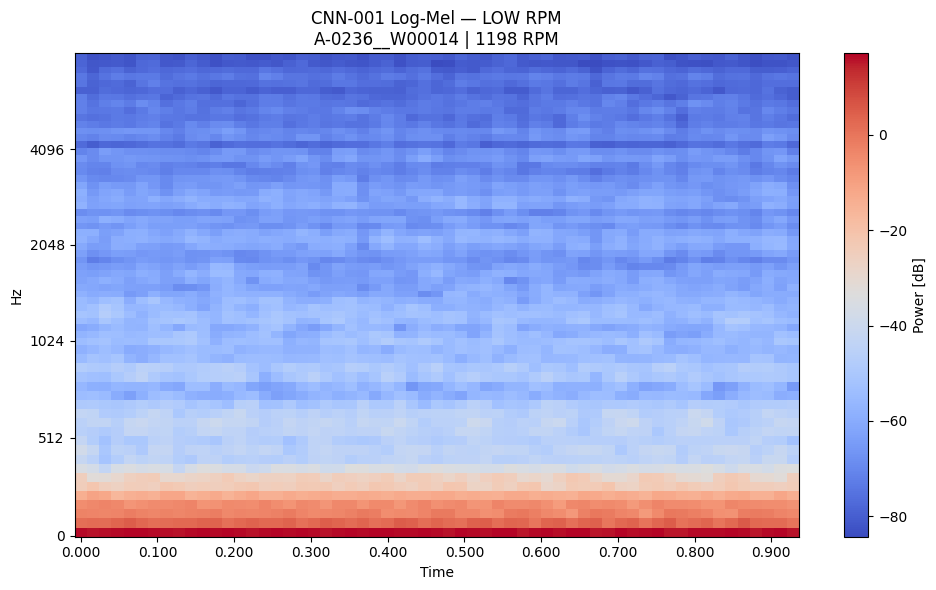

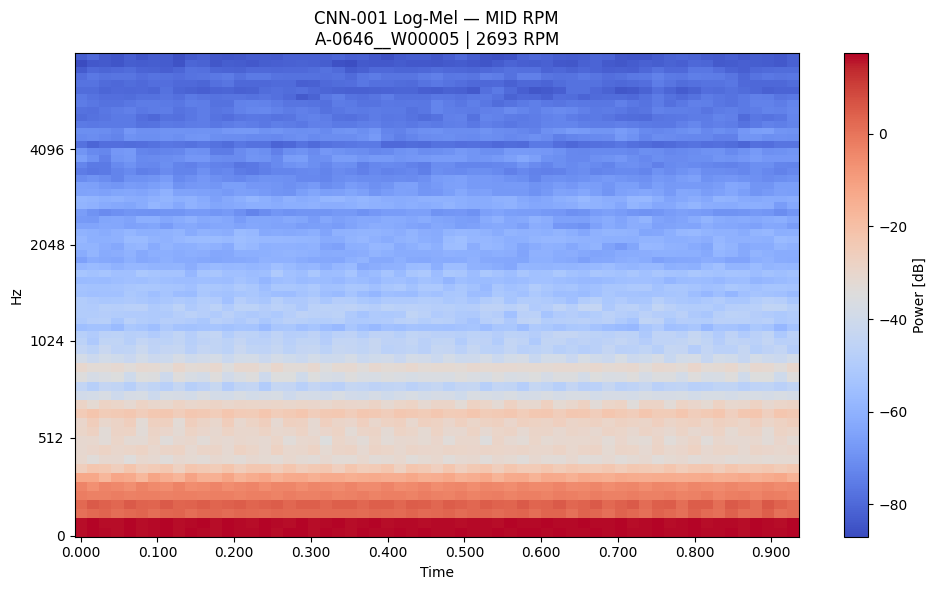

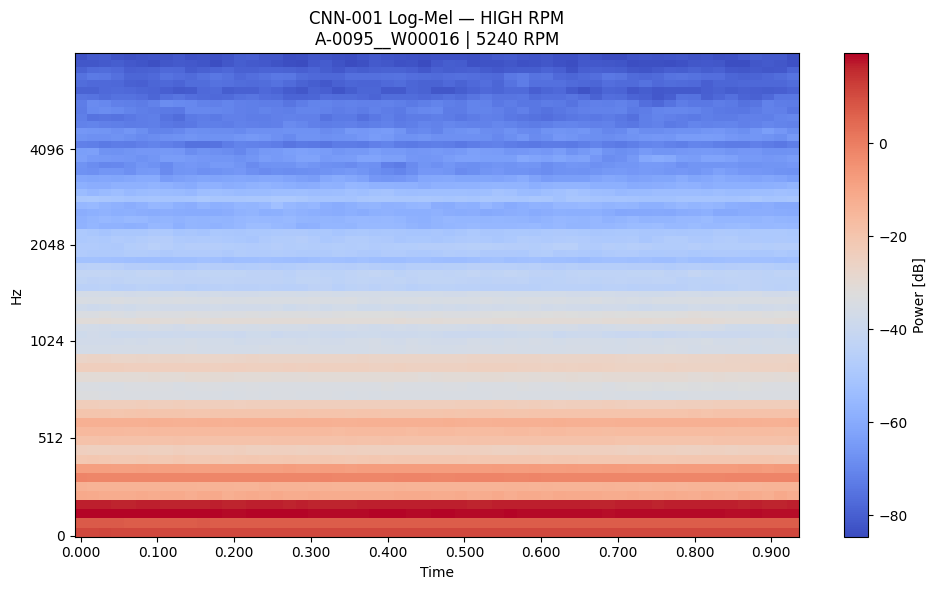

In [25]:
#..Plot
# You should confirm that the log-mels are not blank/corrupt and that
# spectral structure shifts as RPM changes.

import librosa.display

for record in (
    logmel_smoke_records
):

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    image = librosa.display.specshow(
        record[
            "log_mel"
        ],
        sr=
            TARGET_SAMPLE_RATE_HZ,
        hop_length=
            HOP_LENGTH,
        x_axis=
            "time",
        y_axis=
            "mel",
        fmin=
            FMIN_HZ,
        fmax=
            FMAX_HZ,
        ax=ax,
    )

    ax.set_title(
        f"CNN-001 Log-Mel — "
        f"{record['rpm_category'].upper()} RPM\n"
        f"{record['sample_id']} | "
        f"{record['rpm_mean']:.0f} RPM"
    )

    fig.colorbar(
        image,
        ax=ax,
        label="Power [dB]",
    )

    fig.tight_layout()

    output_path = (
        CNN_FIGURE_DIR
        / (
            "logmel_"
            f"{record['rpm_category']}"
            "_rpm_v001.png"
        )
    )

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

In [26]:
# Step 5 — Create persistent CNN-001 log-mel cache

# Step 5A — Ensure h5py is permanent
# ============================================================
# STEP 5A — ENSURE h5py PROJECT DEPENDENCY
# ============================================================

REQUIREMENTS_PATH = (
    REPO_DIR
    / "requirements.txt"
)

requirements_text = (
    REQUIREMENTS_PATH
    .read_text(
        encoding="utf-8"
    )
)

existing_packages = {
    line.strip().lower()
    for line
    in requirements_text.splitlines()
    if line.strip()
}

if "h5py" not in existing_packages:

    with open(
        REQUIREMENTS_PATH,
        "a",
        encoding="utf-8",
    ) as file:

        file.write(
            "\nh5py\n"
        )

    print(
        "Added h5py to requirements.txt."
    )

else:

    print(
        "h5py already listed."
    )

Added h5py to requirements.txt.


In [27]:
#..Install in current runtime (assuming necessity)

!pip install -q h5py

In [28]:
import h5py

print(
    "h5py:",
    h5py.__version__,
)

h5py: 3.16.0


In [29]:
# Step 5B — Persistent cache path

CNN_CACHE_DIR = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "CNN-001"
)

CNN_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CNN_LOGMEL_CACHE_PATH = (
    CNN_CACHE_DIR
    / "logmel_v001.h5"
)

print(
    f"Cache location:\n"
    f"{CNN_LOGMEL_CACHE_PATH}"
)

Cache location:
/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/cached_features/CNN-001/logmel_v001.h5


In [30]:
# Step 5C — Generate the CNN cache

# ============================================================
# STEP 5C — GENERATE CNN-001 LOG-MEL CACHE
# ============================================================

import soundfile as sf

from scipy.signal import (
    resample_poly
)

from tqdm.auto import tqdm


num_samples = len(
    cnn_model_data
)

n_mels_expected = int(
    LOG_MEL_SHAPE[0]
)

n_frames_expected = int(
    LOG_MEL_SHAPE[1]
)

string_dtype = (
    h5py.string_dtype(
        encoding="utf-8"
    )
)


cache_errors = []
cache_row_index = 0


with h5py.File(
    CNN_LOGMEL_CACHE_PATH,
    "w",
) as h5:

    logmel_dataset = (
        h5.create_dataset(
            "log_mel",
            shape=(
                num_samples,
                n_mels_expected,
                n_frames_expected,
            ),
            dtype="float32",
            compression="gzip",
            compression_opts=4,
        )
    )

    sample_id_dataset = (
        h5.create_dataset(
            "sample_id",
            shape=(
                num_samples,
            ),
            dtype=
                string_dtype,
        )
    )

    parent_id_dataset = (
        h5.create_dataset(
            "parent_file_id",
            shape=(
                num_samples,
            ),
            dtype=
                string_dtype,
        )
    )

    split_dataset = (
        h5.create_dataset(
            "split",
            shape=(
                num_samples,
            ),
            dtype=
                string_dtype,
        )
    )

    rpm_dataset = (
        h5.create_dataset(
            "rpm_mean",
            shape=(
                num_samples,
            ),
            dtype=
                "float32",
        )
    )

    torque_dataset = (
        h5.create_dataset(
            "torque_mean_nm",
            shape=(
                num_samples,
            ),
            dtype=
                "float32",
        )
    )


    # --------------------------------------------------------
    # Cache metadata
    # --------------------------------------------------------

    h5.attrs[
        "model_version"
    ] = CNN_VERSION

    h5.attrs[
        "preprocessing_version"
    ] = "PREP-001"

    h5.attrs[
        "split_version"
    ] = "SPLIT-001"

    h5.attrs[
        "sample_manifest_version"
    ] = "SAMPLE-MANIFEST-001"

    h5.attrs[
        "sample_rate_hz"
    ] = TARGET_SAMPLE_RATE_HZ

    h5.attrs[
        "n_fft"
    ] = N_FFT

    h5.attrs[
        "win_length"
    ] = WIN_LENGTH

    h5.attrs[
        "hop_length"
    ] = HOP_LENGTH

    h5.attrs[
        "n_mels"
    ] = N_MELS

    h5.attrs[
        "fmin_hz"
    ] = FMIN_HZ

    h5.attrs[
        "fmax_hz"
    ] = FMAX_HZ


    grouped = (
        cnn_model_data
        .groupby(
            "parent_file_id",
            sort=False,
        )
    )


    for (
        parent_file_id,
        parent_rows
    ) in tqdm(
        grouped,
        total=
            cnn_model_data[
                "parent_file_id"
            ].nunique(),
        desc=
            "Building CNN log-mel cache",
    ):

        first_row = (
            parent_rows.iloc[0]
        )

        wav_path = (
            RAW_ROOT
            / first_row[
                "relative_raw_path"
            ]
        )

        try:

            signal, sample_rate = (
                sf.read(
                    wav_path,
                    always_2d=True,
                )
            )

            if (
                sample_rate
                != SOURCE_SAMPLE_RATE_HZ
            ):

                raise ValueError(
                    "Unexpected source "
                    f"sample rate: {sample_rate}"
                )


            for _, row in (
                parent_rows
                .iterrows()
            ):

                start_sample = int(
                    row[
                        "source_start_sample"
                    ]
                )

                end_sample = int(
                    row[
                        "source_end_sample_exclusive"
                    ]
                )

                source_window = (
                    signal[
                        start_sample:
                        end_sample,
                        :
                    ]
                )

                left = (
                    source_window[
                        :,
                        AUDIO_LEFT_INDEX
                    ]
                )

                right = (
                    source_window[
                        :,
                        AUDIO_RIGHT_INDEX
                    ]
                )

                mono_source = (
                    left + right
                ) / 2.0


                gcd = np.gcd(
                    SOURCE_SAMPLE_RATE_HZ,
                    TARGET_SAMPLE_RATE_HZ,
                )

                mono_model = (
                    resample_poly(
                        mono_source,

                        TARGET_SAMPLE_RATE_HZ
                        // gcd,

                        SOURCE_SAMPLE_RATE_HZ
                        // gcd,
                    )
                )


                expected_length = int(
                    round(
                        WINDOW_DURATION_S
                        * TARGET_SAMPLE_RATE_HZ
                    )
                )

                if (
                    len(mono_model)
                    != expected_length
                ):

                    raise ValueError(
                        f"{row['sample_id']}: "
                        "unexpected model "
                        "audio length "
                        f"{len(mono_model)}"
                    )


                log_mel = (
                    compute_log_mel(
                        audio=
                            mono_model,

                        sample_rate_hz=
                            TARGET_SAMPLE_RATE_HZ,

                        n_fft=
                            N_FFT,

                        win_length=
                            WIN_LENGTH,

                        hop_length=
                            HOP_LENGTH,

                        n_mels=
                            N_MELS,

                        fmin_hz=
                            FMIN_HZ,

                        fmax_hz=
                            FMAX_HZ,
                    )
                )


                if (
                    log_mel.shape
                    != LOG_MEL_SHAPE
                ):

                    raise ValueError(
                        f"{row['sample_id']}: "
                        f"log-mel shape "
                        f"{log_mel.shape}; "
                        f"expected "
                        f"{LOG_MEL_SHAPE}"
                    )


                if not np.isfinite(
                    log_mel
                ).all():

                    raise ValueError(
                        f"{row['sample_id']}: "
                        "non-finite log-mel values"
                    )


                logmel_dataset[
                    cache_row_index
                ] = log_mel

                sample_id_dataset[
                    cache_row_index
                ] = row[
                    "sample_id"
                ]

                parent_id_dataset[
                    cache_row_index
                ] = row[
                    "parent_file_id"
                ]

                split_dataset[
                    cache_row_index
                ] = row[
                    "split"
                ]

                rpm_dataset[
                    cache_row_index
                ] = row[
                    "rpm_mean"
                ]

                torque_dataset[
                    cache_row_index
                ] = row[
                    "torque_mean_nm"
                ]

                cache_row_index += 1


        except Exception as error:

            cache_errors.append(
                {
                    "parent_file_id":
                        parent_file_id,

                    "error":
                        str(error),
                }
            )


print()
print(
    f"Rows written:  "
    f"{cache_row_index:,}"
)

print(
    f"Expected rows: "
    f"{num_samples:,}"
)

print(
    f"Errors:        "
    f"{len(cache_errors)}"
)

Building CNN log-mel cache:   0%|          | 0/680 [00:00<?, ?it/s]


Rows written:  11,646
Expected rows: 11,646
Errors:        0


In [31]:
# Step 5D — Validate cache

# ============================================================
# STEP 5D — VALIDATE CNN CACHE
# ============================================================

if cache_errors:

    cache_error_df = (
        pd.DataFrame(
            cache_errors
        )
    )

    display(
        cache_error_df
    )

    raise RuntimeError(
        "CNN cache generation errors occurred."
    )


assert (
    cache_row_index
    == num_samples
)


with h5py.File(
    CNN_LOGMEL_CACHE_PATH,
    "r",
) as h5:

    print(
        "Cache log-mel shape:",
        h5[
            "log_mel"
        ].shape,
    )

    sample_ids_cache = (
        h5[
            "sample_id"
        ]
        .asstr()[:]
    )

    splits_cache = (
        h5[
            "split"
        ]
        .asstr()[:]
    )


    assert (
        h5[
            "log_mel"
        ].shape
        ==
        (
            num_samples,
            N_MELS,
            LOG_MEL_SHAPE[1],
        )
    )

    assert (
        len(
            np.unique(
                sample_ids_cache
            )
        )
        ==
        len(
            sample_ids_cache
        )
    )

    assert set(
        splits_cache
    ) == {
        "train",
        "validation",
        "test",
    }


    chunk_size = 256

    for start in range(
        0,
        num_samples,
        chunk_size,
    ):

        end = min(
            start
            + chunk_size,
            num_samples,
        )

        block = (
            h5[
                "log_mel"
            ][
                start:end
            ]
        )

        assert np.isfinite(
            block
        ).all()


assert set(
    sample_ids_cache
) == set(
    cnn_model_data[
        "sample_id"
    ]
)


print(
    "PASS: CNN-001 log-mel "
    "cache validated."
)

Cache log-mel shape: (11646, 64, 59)
PASS: CNN-001 log-mel cache validated.


In [32]:
# Step 5E — Fingerprint cache

import hashlib

sha256 = hashlib.sha256()

with open(
    CNN_LOGMEL_CACHE_PATH,
    "rb",
) as file:

    for block in iter(
        lambda:
            file.read(
                1024 * 1024
            ),
        b"",
    ):

        sha256.update(
            block
        )


CNN_LOGMEL_SHA256 = (
    sha256.hexdigest()
)

print(
    "CNN-001 cache SHA-256:"
)

print(
    CNN_LOGMEL_SHA256
)

CNN-001 cache SHA-256:
2cbcf01d0cd61616022a228a97271ae43b642c0148e3cf4f643f647aef9f7aa7


In [33]:
#.. create record

CNN_CACHE_RECORD_PATH = (
    REPO_DIR
    / "data"
    / "cnn001_logmel_cache_v001_record.yaml"
)


cnn_cache_record = {

    "artifact": {

        "name":
            "logmel_v001.h5",

        "model_version":
            CNN_VERSION,

        "status":
            "frozen",

        "storage":
            "Google Drive",

        "logical_path":
            (
                "data/cached_features/"
                "CNN-001/logmel_v001.h5"
            ),

        "sha256":
            CNN_LOGMEL_SHA256,
    },


    "population": {

        "sample_count":
            int(
                len(
                    cnn_model_data
                )
            ),

        "population_filter":
            (
                "model_eligible_rpm_v001 "
                "== True"
            ),
    },


    "representation": {

        "shape_per_sample":
            [
                int(
                    LOG_MEL_SHAPE[0]
                ),
                int(
                    LOG_MEL_SHAPE[1]
                ),
            ],

        "sample_rate_hz":
            TARGET_SAMPLE_RATE_HZ,

        "n_fft":
            N_FFT,

        "win_length":
            WIN_LENGTH,

        "hop_length":
            HOP_LENGTH,

        "n_mels":
            N_MELS,

        "fmin_hz":
            FMIN_HZ,

        "fmax_hz":
            FMAX_HZ,
    },


    "upstream": {

        "preprocessing":
            "PREP-001",

        "split":
            "SPLIT-001",

        "sample_manifest":
            "SAMPLE-MANIFEST-001",
    },
}


with open(
    CNN_CACHE_RECORD_PATH,
    "w",
    encoding="utf-8",
) as file:

    yaml.safe_dump(
        cnn_cache_record,
        file,
        sort_keys=False,
    )


print(
    f"Saved:\n"
    f"{CNN_CACHE_RECORD_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/data/cnn001_logmel_cache_v001_record.yaml


In [34]:
# Session closeout steps

# Close-out 1. Save the representative-sample table

# ============================================================
# CLOSEOUT 1 — SAVE CNN REPRESENTATIVE SAMPLE TABLE
# ============================================================

CNN_FIGURE_DIR = (
    FIGURE_DIR
    / "cnn_rpm"
)

CNN_TABLE_DIR = (
    TABLE_DIR
    / "cnn_rpm"
)

CNN_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CNN_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CNN_REPRESENTATIVE_SAMPLE_PATH = (
    CNN_TABLE_DIR
    / "cnn001_representative_samples_v001.csv"
)

columns_to_save = [
    "rpm_category",
    "sample_id",
    "parent_file_id",
    "split",
    "rpm_mean",
    "torque_mean_nm",
    "rpm_range",
]

available_columns = [
    column
    for column in columns_to_save
    if column in cnn_representative_samples.columns
]

cnn_representative_samples[
    available_columns
].to_csv(
    CNN_REPRESENTATIVE_SAMPLE_PATH,
    index=False,
)

print(
    f"Saved:\n"
    f"{CNN_REPRESENTATIVE_SAMPLE_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/results/tables/cnn_rpm/cnn001_representative_samples_v001.csv


In [35]:
# ..verify

rep_check = pd.read_csv(
    CNN_REPRESENTATIVE_SAMPLE_PATH
)

assert len(rep_check) == 3

assert set(
    rep_check[
        "rpm_category"
    ]
) == {
    "low",
    "mid",
    "high",
}

print(
    "PASS: CNN representative samples saved."
)

PASS: CNN representative samples saved.


In [36]:
# Close-out 2. Verify the persistent CNN log-mel cache

# ============================================================
# CLOSEOUT 2 — VERIFY PERSISTENT CNN-001 CACHE
# ============================================================

import h5py
import hashlib
import yaml
import numpy as np

assert CNN_LOGMEL_CACHE_PATH.exists(), (
    "CNN-001 HDF5 cache is missing:\n"
    f"{CNN_LOGMEL_CACHE_PATH}"
)

assert CNN_CACHE_RECORD_PATH.exists(), (
    "CNN-001 cache record is missing:\n"
    f"{CNN_CACHE_RECORD_PATH}"
)


with h5py.File(
    CNN_LOGMEL_CACHE_PATH,
    "r",
) as h5:

    cache_shape = (
        h5[
            "log_mel"
        ].shape
    )

    cache_sample_ids = (
        h5[
            "sample_id"
        ]
        .asstr()[:]
    )

    cache_splits = (
        h5[
            "split"
        ]
        .asstr()[:]
    )

    print(
        "Cache shape:",
        cache_shape,
    )

    print(
        "Samples:",
        len(
            cache_sample_ids
        ),
    )

    print(
        "Splits:",
        set(
            cache_splits
        ),
    )

    assert (
        cache_shape[0]
        ==
        len(
            cache_sample_ids
        )
    )

    assert (
        len(
            np.unique(
                cache_sample_ids
            )
        )
        ==
        len(
            cache_sample_ids
        )
    )

    assert set(
        cache_splits
    ) == {
        "train",
        "validation",
        "test",
    }


print(
    "PASS: Persistent CNN cache structure valid."
)

Cache shape: (11646, 64, 59)
Samples: 11646
Splits: {'train', 'validation', 'test'}
PASS: Persistent CNN cache structure valid.


In [37]:
# Close-out 3. Recalculate the SHA-256 and compare with the GitHub record
# This proves tomorrow's HDF5 is exactly today's cache

# ============================================================
# CLOSEOUT 3 — VERIFY CNN CACHE FINGERPRINT
# ============================================================

sha256 = hashlib.sha256()

with open(
    CNN_LOGMEL_CACHE_PATH,
    "rb",
) as file:

    for block in iter(
        lambda:
            file.read(
                1024 * 1024
            ),
        b"",
    ):

        sha256.update(
            block
        )


current_cache_sha256 = (
    sha256.hexdigest()
)


with open(
    CNN_CACHE_RECORD_PATH,
    "r",
    encoding="utf-8",
) as file:

    cache_record_check = (
        yaml.safe_load(
            file
        )
    )


recorded_cache_sha256 = (
    cache_record_check[
        "artifact"
    ]["sha256"]
)


print(
    "Current :",
    current_cache_sha256,
)

print(
    "Recorded:",
    recorded_cache_sha256,
)


assert (
    current_cache_sha256
    ==
    recorded_cache_sha256
)


print(
    "PASS: CNN-001 cache fingerprint matches."
)

Current : 2cbcf01d0cd61616022a228a97271ae43b642c0148e3cf4f643f647aef9f7aa7
Recorded: 2cbcf01d0cd61616022a228a97271ae43b642c0148e3cf4f643f647aef9f7aa7
PASS: CNN-001 cache fingerprint matches.


In [38]:
# Close-out 4. Verify today's GitHub-side artifacts
# You want: All expected artifacts present: True

# ============================================================
# CLOSEOUT 4 — NOTEBOOK 08 PARTIAL ARTIFACT AUDIT
# ============================================================

expected_outputs = [
    "configs/cnn_rpm_v001.yaml",
    "src/spectrogram_features.py",
    "data/cnn001_logmel_cache_v001_record.yaml",
    "results/tables/cnn_rpm/cnn001_representative_samples_v001.csv",
    "results/figures/cnn_rpm/logmel_low_rpm_v001.png",
    "results/figures/cnn_rpm/logmel_mid_rpm_v001.png",
    "results/figures/cnn_rpm/logmel_high_rpm_v001.png",
    "requirements.txt",
]

all_present = True

print(
    "Notebook 08 partial-stage artifact audit"
)

print(
    "=" * 72
)

for relative_path in expected_outputs:

    full_path = (
        REPO_DIR
        / relative_path
    )

    if full_path.exists():

        print(
            f"PASS : {relative_path}"
        )

    else:

        print(
            f"MISSING : {relative_path}"
        )

        all_present = False


print()

print(
    "All expected artifacts present:",
    all_present,
)

Notebook 08 partial-stage artifact audit
PASS : configs/cnn_rpm_v001.yaml
PASS : src/spectrogram_features.py
PASS : data/cnn001_logmel_cache_v001_record.yaml
PASS : results/tables/cnn_rpm/cnn001_representative_samples_v001.csv
PASS : results/figures/cnn_rpm/logmel_low_rpm_v001.png
PASS : results/figures/cnn_rpm/logmel_mid_rpm_v001.png
PASS : results/figures/cnn_rpm/logmel_high_rpm_v001.png
PASS : requirements.txt

All expected artifacts present: True


In [39]:
# Close-out 5. Confirm h5py is permanently in requirements.txt

# ============================================================
# CLOSEOUT 5 — VERIFY h5py DEPENDENCY
# ============================================================

REQUIREMENTS_PATH = (
    REPO_DIR
    / "requirements.txt"
)

requirements_lines = [
    line.strip().lower()
    for line
    in REQUIREMENTS_PATH
    .read_text(
        encoding="utf-8"
    )
    .splitlines()
    if line.strip()
]

assert "h5py" in requirements_lines

print(
    "PASS: h5py recorded in requirements.txt."
)

PASS: h5py recorded in requirements.txt.
